<a href="https://colab.research.google.com/github/Amar13-web/three-body-gravitational-simulator/blob/main/N_Body_Gravitational_Simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# N-Body Gravitational Simulator

I made this project to explore how Python can be used to simulate the motion of objects interacting through gravity.

The idea is to start with the positions, velocities and masses of several bodies and then calculate how their motion changes over time due to the gravitational forces between them.

I wanted to use a problem that becomes difficult to solve analytically once several bodies are involved and see how numerical methods can be used to model the system instead.

## What I wanted to investigate

- How gravitational interactions between several bodies can be calculated
- How the acceleration of each body changes as the system evolves
- How numerical methods can be used to update velocity and position over time
- How the resulting orbital paths can be visualised
- How well the simulation conserves total energy
- How changing the starting conditions affects the motion of the system

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Physical Model

The simulation is based on Newton's law of universal gravitation. For two bodies with masses \(m_1\) and \(m_2\), the magnitude of the gravitational force between them is

$$
F = \frac{Gm_1m_2}{r^2}
$$

where \(G\) is the gravitational constant and \(r\) is the distance between the two bodies.

For a system containing several bodies, each body can experience gravitational forces from all of the others. I calculate these interactions separately and then add them together to find the overall effect on each body.

In [ ]:
G = 6.67430e-11

## Initial System

I started with a simplified three-body system containing the Sun, Earth and Jupiter.

For each body, I defined its mass, starting position and starting velocity. The values are approximate and give me a useful starting point for testing the simulation before experimenting with more complicated systems.

In [ ]:
names = ["Sun", "Earth", "Jupiter"]

masses = np.array([
    1.989e30,
    5.972e24,
    1.898e27
])

positions = np.array([
    [0.0, 0.0],
    [1.496e11, 0.0],
    [7.785e11, 0.0]
], dtype=float)

velocities = np.array([
    [0.0, 0.0],
    [0.0, 29780.0],
    [0.0, 13070.0]
], dtype=float)

## Calculating Gravitational Acceleration

The next step is to calculate the acceleration of each body.

Starting with Newton's gravitational force,

$$
F = \frac{Gm_im_j}{r^2}
$$

and using \(F = ma\), the acceleration of body \(i\) caused by body \(j\) can be written in vector form as

$$
\mathbf{a}_i =
Gm_j
\frac{\mathbf{r}_{ij}}
{|\mathbf{r}_{ij}|^3}
$$

Here, \(\mathbf{r}_{ij}\) is the displacement vector pointing from body \(i\) towards body \(j\).

For each body, I calculate this acceleration for every other body in the system and add the contributions together. This gives the total gravitational acceleration acting on that body at that point in time.

In [ ]:
def calculate_accelerations(positions, masses):
    number_of_bodies = len(masses)

    accelerations = np.zeros_like(positions)

    for i in range(number_of_bodies):
        for j in range(number_of_bodies):

            if i != j:
                displacement = positions[j] - positions[i]
                distance = np.linalg.norm(displacement)

                accelerations[i] += (
                    G
                    * masses[j]
                    * displacement
                    / distance**3
                )

    return accelerations

In [ ]:
initial_accelerations = calculate_accelerations(
    positions,
    masses
)

initial_accelerations

array([[ 2.26828421e-07,  0.00000000e+00],
       [-5.93135433e-03,  0.00000000e+00],
       [-2.19040928e-04,  0.00000000e+00]])

## Updating the Motion

At each time step, the gravitational acceleration of every body is calculated from its current position.

I then use this acceleration to update the velocity and position of each body.

For a small time interval \(\Delta t\), the velocity can be updated using

$$
\mathbf{v}(t+\Delta t)
=
\mathbf{v}(t)
+
\mathbf{a}(t)\Delta t
$$

and the position can be updated using

$$
\mathbf{r}(t+\Delta t)
=
\mathbf{r}(t)
+
\mathbf{v}(t+\Delta t)\Delta t
$$

This process is repeated many times so that the full motion of the system can be built up step by step.

In [ ]:
time_step = 60 * 60 * 6
simulation_years = 12

total_time = simulation_years * 365.25 * 24 * 60 * 60
number_of_steps = int(total_time / time_step)

number_of_steps

17532

## Storing the Trajectories

To plot the orbits later, I need to keep track of the position of every body throughout the simulation.

I created an array that stores the \(x\) and \(y\) position of each body at every time step.

In [ ]:
number_of_bodies = len(masses)

trajectory = np.zeros(
    (number_of_steps, number_of_bodies, 2)
)

trajectory[0] = positions

## Running the Simulation

The simulation now repeats the same process at every time step:

1. Calculate the gravitational acceleration of each body.
2. Update the velocities.
3. Update the positions.
4. Store the new positions.

Repeating this thousands of times produces the orbital trajectories.

In [ ]:
current_positions = positions.copy()
current_velocities = velocities.copy()

for step in range(1, number_of_steps):
    accelerations = calculate_accelerations(
        current_positions,
        masses
    )

    current_velocities += accelerations * time_step
    current_positions += current_velocities * time_step

    trajectory[step] = current_positions

## Plotting the Orbits

After storing the positions throughout the simulation, I plotted the trajectory of each body.

This gives a visual picture of how the Sun, Earth and Jupiter move under their mutual gravitational interaction.

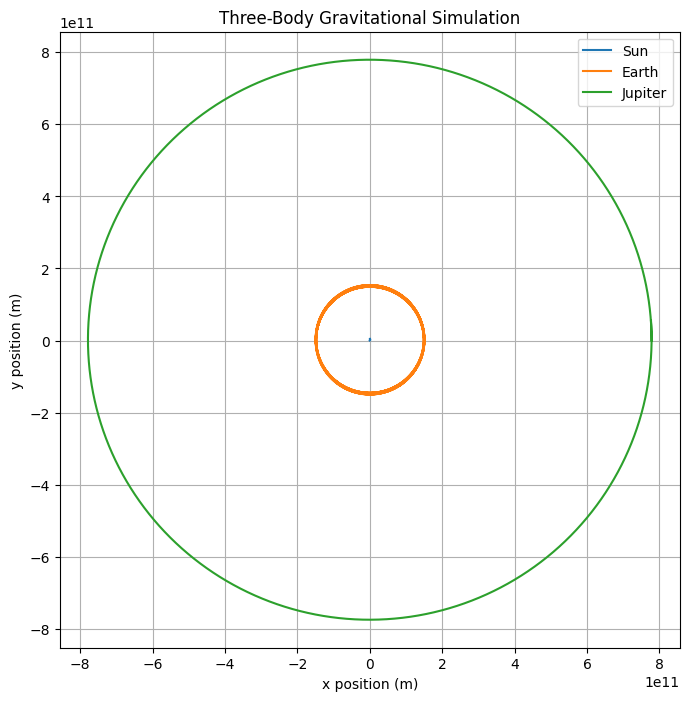

In [ ]:
plt.figure(figsize=(8, 8))

for i, name in enumerate(names):
    plt.plot(
        trajectory[:, i, 0],
        trajectory[:, i, 1],
        label=name
    )

plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
plt.title("Three-Body Gravitational Simulation")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

## Checking Energy Conservation

A useful way to test the quality of the simulation is to look at the total mechanical energy of the system.

For each body, the kinetic energy is

$$
K = \frac{1}{2}mv^2
$$

and for a pair of bodies, the gravitational potential energy is

$$
U = -\frac{Gm_im_j}{r_{ij}}
$$

The total energy of the system is the sum of all kinetic and gravitational potential energy.

For an ideal isolated gravitational system, the total energy should remain constant. In a numerical simulation, small changes can appear because the motion is only being approximated at discrete time steps.


In [ ]:
def total_energy(positions, velocities, masses):
    kinetic_energy = 0.0
    potential_energy = 0.0

    number_of_bodies = len(masses)

    for i in range(number_of_bodies):
        speed_squared = np.dot(
            velocities[i],
            velocities[i]
        )

        kinetic_energy += (
            0.5
            * masses[i]
            * speed_squared
        )

    for i in range(number_of_bodies):
        for j in range(i + 1, number_of_bodies):
            displacement = positions[j] - positions[i]
            distance = np.linalg.norm(displacement)

            potential_energy -= (
                G
                * masses[i]
                * masses[j]
                / distance
            )

    return kinetic_energy + potential_energy

## Tracking the Energy

To check energy conservation, I ran the simulation again while storing the total mechanical energy at each time step.

If the numerical method is behaving well, the total energy should stay close to its starting value throughout the simulation.

In [ ]:
current_positions = positions.copy()
current_velocities = velocities.copy()

energy_history = np.zeros(number_of_steps)

trajectory = np.zeros(
    (number_of_steps, number_of_bodies, 2)
)

trajectory[0] = current_positions

energy_history[0] = total_energy(
    current_positions,
    current_velocities,
    masses
)

for step in range(1, number_of_steps):
    accelerations = calculate_accelerations(
        current_positions,
        masses
    )

    current_velocities += accelerations * time_step
    current_positions += current_velocities * time_step

    trajectory[step] = current_positions

    energy_history[step] = total_energy(
        current_positions,
        current_velocities,
        masses
    )

## Energy Change Over Time

Rather than plotting the very large total energy directly, I calculated the fractional change relative to the initial value.

This makes it easier to see whether the simulation is gradually gaining or losing energy because of numerical error.

The fractional energy change is

$$
\frac{E(t)-E_0}{|E_0|}
$$

where \(E_0\) is the total energy at the start of the simulation.

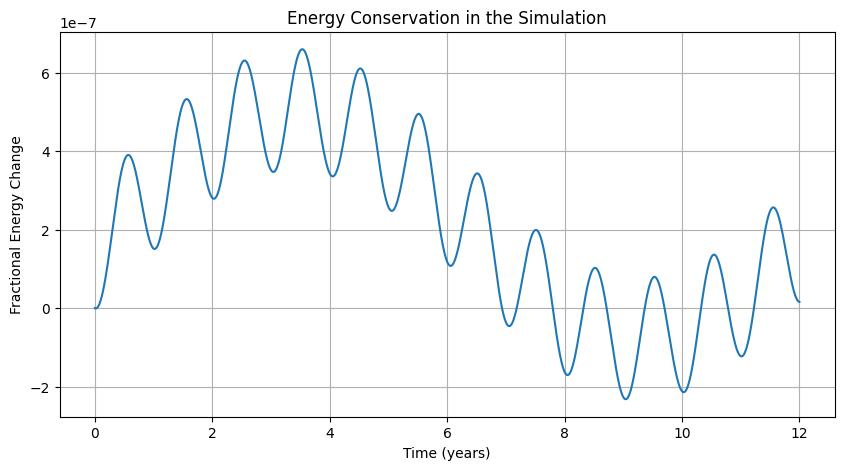

In [ ]:
fractional_energy_change = (
    energy_history - energy_history[0]
) / abs(energy_history[0])

time_years = (
    np.arange(number_of_steps)
    * time_step
    / (365.25 * 24 * 60 * 60)
)

plt.figure(figsize=(10, 5))

plt.plot(
    time_years,
    fractional_energy_change
)

plt.xlabel("Time (years)")
plt.ylabel("Fractional Energy Change")
plt.title("Energy Conservation in the Simulation")
plt.grid(True)

plt.show()

### Energy Conservation Result

The total energy remained very close to its initial value throughout the simulation. The fractional change stayed on the order of $10^{-7}$, showing that the numerical error was very small over the simulated period.

The small oscillations are caused by the numerical integration method rather than a physical gain or loss of energy. Since the error remains small and bounded, the simulation reproduces the expected conservation of mechanical energy well.

## Checking Angular Momentum Conservation

Another useful test is to check whether the total angular momentum of the system stays approximately constant.

For a body with position vector \(\mathbf{r}\), momentum \(\mathbf{p}=m\mathbf{v}\), the angular momentum is

$$
\mathbf{L} = \mathbf{r} \times \mathbf{p}
$$

Because the simulation is two-dimensional, I only need the component perpendicular to the orbital plane.

For an isolated gravitational system, the total angular momentum should remain constant. Any small variation in the simulation comes from numerical error.

In [ ]:
def total_angular_momentum(positions, velocities, masses):
    angular_momentum = 0.0

    for i in range(len(masses)):
        x, y = positions[i]
        vx, vy = velocities[i]

        angular_momentum += masses[i] * (x * vy - y * vx)

    return angular_momentum

## Tracking Angular Momentum

I ran the simulation again while storing the total angular momentum at each time step.

I then compared it with the initial angular momentum to see how much it changed over the full simulation.

In [ ]:
current_positions = positions.copy()
current_velocities = velocities.copy()

angular_momentum_history = np.zeros(number_of_steps)

angular_momentum_history[0] = total_angular_momentum(
    current_positions,
    current_velocities,
    masses
)

for step in range(1, number_of_steps):
    accelerations = calculate_accelerations(
        current_positions,
        masses
    )

    current_velocities += accelerations * time_step
    current_positions += current_velocities * time_step

    angular_momentum_history[step] = total_angular_momentum(
        current_positions,
        current_velocities,
        masses
    )

## Angular Momentum Change Over Time

To make the change easier to interpret, I plotted the fractional change in angular momentum relative to its initial value.

$$
\frac{L(t)-L_0}{|L_0|}
$$

If the simulation is behaving well, this value should remain close to zero.

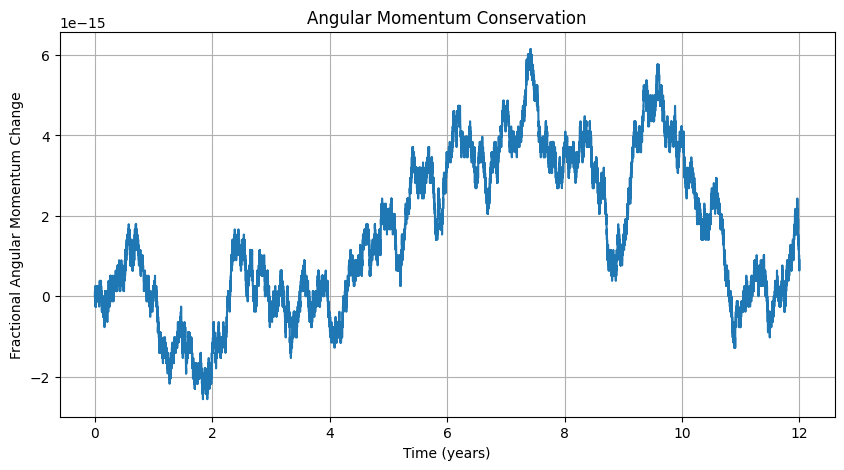

In [ ]:
fractional_angular_momentum_change = (
    angular_momentum_history - angular_momentum_history[0]
) / abs(angular_momentum_history[0])

plt.figure(figsize=(10, 5))

plt.plot(
    time_years,
    fractional_angular_momentum_change
)

plt.xlabel("Time (years)")
plt.ylabel("Fractional Angular Momentum Change")
plt.title("Angular Momentum Conservation")
plt.grid(True)

plt.show()

### Angular Momentum Conservation Result

The total angular momentum remained effectively constant throughout the simulation. The fractional change was only on the order of $10^{-15}$, which is extremely small and close to the numerical precision of the calculation.

This gives another useful check that the simulation is behaving as expected. Although the plotted values fluctuate slightly around zero, the size of these changes is negligible compared with the total angular momentum of the system.

## Investigating the Effect of Jupiter's Mass

Now that I have checked the numerical stability of the model, I wanted to use it to investigate how changing one part of the system affects the others.

Jupiter is much more massive than Earth, so I decided to increase Jupiter's mass and examine how this changes Earth's motion.

I will compare the original simulation with cases where Jupiter has 5, 10 and 20 times its actual mass. Everything else in the model will remain unchanged, allowing the effect of Jupiter's mass to be isolated.

In [ ]:
jupiter_mass_factors = [1, 5, 10, 20]

earth_trajectories = {}

for factor in jupiter_mass_factors:

    modified_masses = masses.copy()
    modified_masses[2] = masses[2] * factor

    current_positions = positions.copy()
    current_velocities = velocities.copy()

    earth_path = np.zeros((number_of_steps, 2))
    earth_path[0] = current_positions[1]

    for step in range(1, number_of_steps):

        accelerations = calculate_accelerations(
            current_positions,
            modified_masses
        )

        current_velocities += accelerations * time_step
        current_positions += current_velocities * time_step

        earth_path[step] = current_positions[1]

    earth_trajectories[factor] = earth_path

### Comparing Earth's Orbit

The trajectories below show how Earth's orbit changes as Jupiter's mass is increased.

The case labelled $1\times$ represents Jupiter at its actual mass and provides the baseline for comparison. The other trajectories show the effect of making Jupiter progressively more massive.

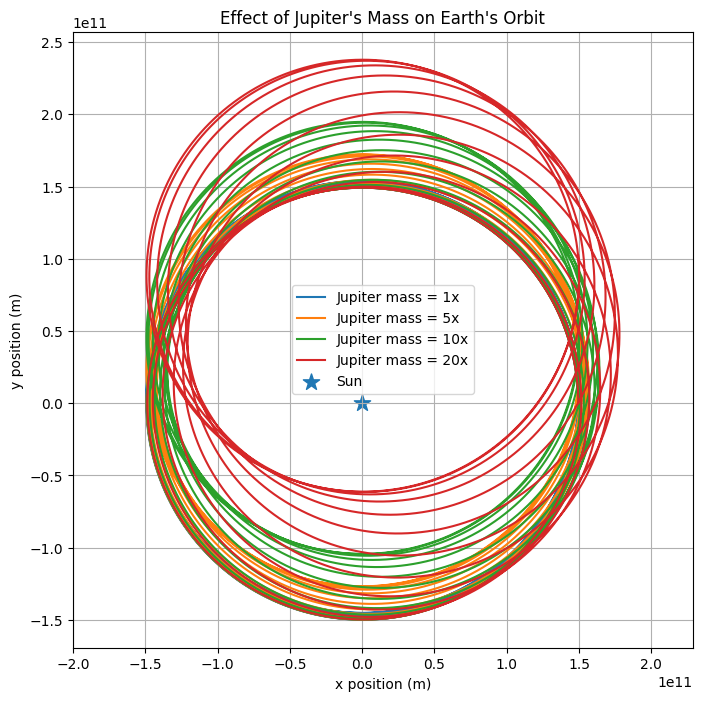

In [ ]:
plt.figure(figsize=(8, 8))

for factor, trajectory in earth_trajectories.items():
    plt.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        label=f"Jupiter mass = {factor}x"
    )

plt.scatter(0, 0, marker="*", s=150, label="Sun")

plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
plt.title("Effect of Jupiter's Mass on Earth's Orbit")

plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

### Effect of Increasing Jupiter's Mass

Increasing Jupiter's mass produced a clear change in Earth's trajectory.

With Jupiter at its actual mass, Earth's orbit remained relatively close to its original path. As Jupiter's mass was increased, the perturbations became progressively larger. The effect is particularly noticeable for the 10x and 20x cases, where Earth's path varies much more over the course of the simulation.

This makes sense physically because increasing Jupiter's mass increases the gravitational force it exerts on the other bodies. The experiment shows how changing the mass of one body in a gravitational system can significantly affect the motion of another, even though the two bodies are separated by a large distance.

The 20x case shows the strongest perturbation, although the simulation is not long enough to determine the long-term stability of the orbit.

## Measuring the Change in Earth's Orbit

The trajectories show that increasing Jupiter's mass changes Earth's orbit, but I also wanted to measure the size of this effect.

For each simulation, I calculated Earth's distance from the Sun using

$$
r = \sqrt{x^2 + y^2}
$$

I then found the minimum and maximum distance reached during the simulation. This gives a simple way of comparing how much Earth's orbital distance changes as Jupiter becomes more massive.

In [ ]:
import pandas as pd

AU = 1.496e11

orbital_results = []

for factor, trajectory in earth_trajectories.items():

    distances = np.sqrt(
        trajectory[:, 0]**2 + trajectory[:, 1]**2
    )

    min_distance = distances.min() / AU
    max_distance = distances.max() / AU
    distance_range = max_distance - min_distance

    orbital_results.append({
        "Jupiter Mass": f"{factor}x",
        "Minimum Distance (AU)": min_distance,
        "Maximum Distance (AU)": max_distance,
        "Orbital Range (AU)": distance_range
    })

orbital_results_df = pd.DataFrame(orbital_results)

orbital_results_df.round(3)

,Jupiter Mass,Minimum Distance (AU),Maximum Distance (AU),Orbital Range (AU)
0,1x,0.970,1.029,0.059
1,5x,0.847,1.152,0.305
2,10x,0.697,1.302,0.605
3,20x,0.409,1.589,1.180


### Results

The numerical results support what can be seen in the orbital trajectories. With Jupiter at its actual mass, Earth's distance from the Sun varied between approximately 0.970 AU and 1.029 AU, giving a range of 0.059 AU.

Increasing Jupiter's mass made this variation much larger. At 5 times Jupiter's mass, the range increased to 0.305 AU, and at 10 times its mass it increased to 0.605 AU.

The largest effect occurred when Jupiter's mass was increased by a factor of 20. Earth's distance from the Sun then varied between approximately 0.409 AU and 1.589 AU, giving a range of 1.180 AU.

This is around 20 times the orbital range found in the original simulation. The results show that a sufficiently large increase in Jupiter's mass can strongly perturb Earth's orbit over the period studied.

## Limitations

There are several limitations to this model.

The simulation only includes the Sun, Earth and Jupiter, while the real Solar System contains many other bodies whose gravitational effects have been ignored.

The model also treats each body as a point mass and only considers Newtonian gravity. Effects such as general relativity and interactions with the other planets are not included.

Another limitation is the numerical method. The motion is calculated using discrete time steps, so a small amount of numerical error is introduced. This can be seen in the energy conservation test, although the fractional error remained very small over the simulation.

Finally, the simulation covers only around 12 years. The Jupiter mass experiment therefore shows how Earth's orbit responds over this period, but it cannot be used to make conclusions about the long-term stability of the Solar System.

## Conclusion

In this project, I built a numerical three-body model to simulate the gravitational interaction between the Sun, Earth and Jupiter.

The initial simulation reproduced the expected orbital behaviour of Earth and Jupiter around the Sun. I then tested the reliability of the model by checking conservation of energy and angular momentum. The fractional energy change remained on the order of $10^{-7}$, while the fractional angular momentum change was around $10^{-15}$.

I then used the model to investigate how increasing Jupiter's mass affects Earth's orbit. With Jupiter at its actual mass, Earth's distance from the Sun varied by approximately 0.059 AU. When Jupiter's mass was increased to 20 times its actual value, this range increased to approximately 1.180 AU.

This showed how a change to one body in a gravitational system can have a significant effect on the motion of another. It also gave me experience using Python to turn the equations of Newtonian mechanics into a numerical model and then testing whether the results were physically reasonable.

## Tools and Methods

- Python
- NumPy
- Matplotlib
- Numerical integration
- Newtonian mechanics
- Conservation of energy
- Conservation of angular momentum
- Data visualisation